# Session 4 — Model Interpretation and Trust

**Practical AI & Machine Learning for Materials Science · ACerS short course**

In this notebook you will:
1. **Garbage in → garbage out:** find and fix problems in a raw dataset, and measure the cost of skipping this step.
2. Extract **feature importances** (and learn why the default ones can mislead).
3. Use **partial dependence** to pull physical insight out of a black-box model.
4. Attach **uncertainty** to predictions and check whether it can be trusted.
5. Probe **failure modes**: new chemistries, extrapolation, and the domain of applicability.

> **Core message:** garbage in → garbage out. This is the most important lesson in the course.

**Optional pre-watch:** "Best practices" and "Extrapolation" lectures on the
[course YouTube playlist](https://youtube.com/playlist?list=PLL0SWcFqypCl4lrzk1dMWwTUrzQZFt7y0).
Slides: [17. Best practices](https://github.com/sp8rks/MaterialsInformatics/blob/main/course_notes/17.%20best%20practices.pdf),
[20. Extrapolation](https://github.com/sp8rks/MaterialsInformatics/blob/main/course_notes/20.%20Extrapolation.pdf).

## 0. Setup

In [1]:
# --- Setup: works locally and in Google Colab ---------------------------------
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/sp8rks/ACerS_AI_ML_Workshop"
if "google.colab" in sys.modules:
    ROOT = Path("/content/ACerS_AI_ML_Workshop")
    if not ROOT.exists():
        subprocess.run(["git", "clone", "-q", REPO_URL, str(ROOT)], check=True)
else:
    ROOT = Path.cwd().resolve()
    while not (ROOT / "workshop_utils").exists() and ROOT != ROOT.parent:
        ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("Workshop root:", ROOT)

Workshop root: C:\ACERS_AI_ML


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from workshop_utils import load_dataset, generate_features, parse_formula, parity_plot

plt.rcParams["figure.dpi"] = 110
RNG = 0

## Part A — Garbage in, garbage out

`heat_capacity_raw.csv` is the heat-capacity dataset *as originally compiled*, before cleaning. Let's be skeptical.

In [3]:
raw = load_dataset("heat_capacity_raw")
raw.columns = ["formula", "T", "Cp"]          # friendlier names
print(raw.shape)
raw.describe()

(4583, 3)


,T,Cp
count,4579.000000,4576.000000
mean,1170.920341,107.483627
std,741.254366,67.019055
min,-2000.000000,-102.215000
25%,600.000000,61.312500
50%,1000.000000,89.497000
75%,1600.000000,135.645000
max,4700.000000,494.967000


In [4]:
print("Missing values per column:\n", raw.isna().sum(), "\n")
print("Non-physical temperatures (T <= 0 K):", (raw["T"] <= 0).sum())
print("Non-physical heat capacities (Cp <= 0):", (raw["Cp"] <= 0).sum())
raw[(raw["T"] <= 0) | (raw["Cp"] <= 0)]

Missing values per column:
 formula    4
T          4
Cp         7
dtype: int64 

Non-physical temperatures (T <= 0 K): 6
Non-physical heat capacities (Cp <= 0): 3


,formula,T,Cp
2506,Mg2O4Ti1,-2000.0,218.840
3152,Nb1,700.0,-26.769
3603,F1Li1,0.0,70.549
3737,Mg1,-1900.0,56.613
3745,Mg1,-1100.0,35.214
3762,Mg2Si1,2000.0,-102.215
3928,Na2S1,0.0,88.701
3932,Na2S1,0.0,82.843
4398,Pb1S1,298.0,-49.438


✏️ **Exercise (5 min):** before running the next cell, write down every check you would apply. Some ideas: missing values, non-physical values, unparseable formulas, exact duplicates, and the same (formula, T) pair with conflicting values.

In [5]:
def clean(df):
    df = df.dropna()
    df = df[(df["T"] > 0) & (df["Cp"] > 0)]
    ok = []
    for f in df["formula"]:
        try:
            parse_formula(f); ok.append(True)
        except ValueError:
            ok.append(False)
    df = df[ok]
    df = df.drop_duplicates()
    return df.reset_index(drop=True)

cleaned = clean(raw)
print(f"raw: {len(raw)} rows  →  cleaned: {len(cleaned)} rows")

raw: 4583 rows  →  cleaned: 4544 rows


A few dozen bad rows out of ~4,500 sounds harmless. Let's measure it. We train on raw vs. cleaned data and **evaluate both on the same clean held-out compounds** (grouped by formula, as in Session 3).

In [6]:
def featurize_cp(df):
    X, _, f, _ = generate_features(df.rename(columns={"Cp": "target"}), "oliynyk",
                                   drop_duplicates=False, verbose=False)
    X = X.filter(like="avg_").copy()
    X["T"] = df["T"].values
    return X, df["Cp"].values, f.values

raw_ok = raw.dropna(subset=["formula"]).fillna({"T": raw["T"].median(), "Cp": raw["Cp"].median()})
Xr, yr, fr = featurize_cp(raw_ok)        # "raw": naive median-imputation, nothing else
Xc, yc, fc = featurize_cp(cleaned)

test_formulas = pd.Series(fc).drop_duplicates().sample(frac=0.2, random_state=RNG)
in_test_c = np.isin(fc, test_formulas)
in_test_r = np.isin(fr, test_formulas)

maes = {}
for name, (X, y, mask) in {"trained on raw": (Xr, yr, in_test_r),
                            "trained on cleaned": (Xc, yc, in_test_c)}.items():
    m = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=RNG).fit(X[~mask], y[~mask])
    maes[name] = mean_absolute_error(yc[in_test_c], m.predict(Xc[in_test_c]))
    print(f"{name:20s} → MAE on clean test compounds = {maes[name]:.1f} J/mol·K")

trained on raw       → MAE on clean test compounds = 22.4 J/mol·K


trained on cleaned   → MAE on clean test compounds = 21.0 J/mol·K


Here the damage is modest: only ~40 of ~4,500 rows were bad, and they are obvious once plotted. The predictions for the affected compounds (Mg, Mg₂Si, PbS…) are pulled toward nonsense, though, and a 2% error in a headline metric is easy to miss. In real projects the problems are subtler and more common: unit mix-ups (kJ vs J, °C vs K), per-atom vs per-formula-unit values, copy-paste errors, and inconsistent definitions across sources. **Plot everything. Check the extremes by hand.**

## Part B — What did the model learn? Feature importance

Back to bulk modulus. We'll use the 44 composition-averaged Oliynyk features so the names stay readable.

In [7]:
df = load_dataset("bulk_modulus")
X, y, formulae, _ = generate_features(df, "oliynyk")
X = X.filter(like="avg_")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RNG)
f_tr, f_te = formulae.loc[X_tr.index], formulae.loc[X_te.index]

rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RNG).fit(X_tr, y_tr)
print(f"Test MAE: {mean_absolute_error(y_te, rf.predict(X_te)):.1f} GPa")

Featurized 4873 formulas into 264 'oliynyk' features (skipped 32)


Test MAE: 12.0 GPa


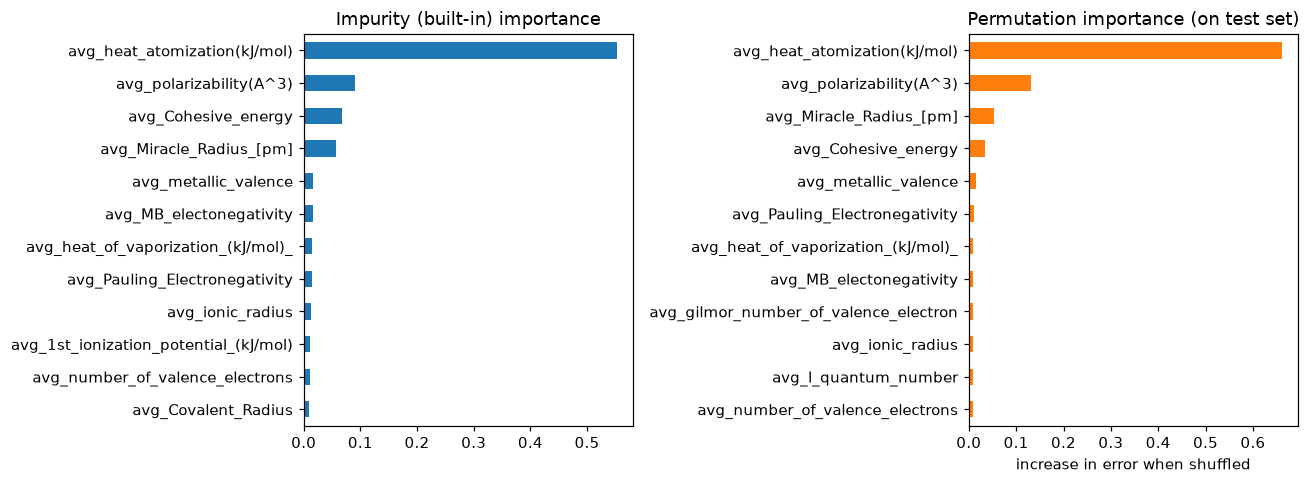

In [8]:
impurity = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
perm = permutation_importance(rf, X_te, y_te, n_repeats=5, random_state=RNG, n_jobs=-1)
perm = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
impurity.head(12)[::-1].plot.barh(ax=axes[0], color="tab:blue", title="Impurity (built-in) importance")
perm.head(12)[::-1].plot.barh(ax=axes[1], color="tab:orange", title="Permutation importance (on test set)")
axes[1].set_xlabel("increase in error when shuffled")
plt.tight_layout()
plt.show()

**How to read these honestly:**
- *Impurity* importance is computed on training data and is biased toward continuous, high-cardinality features.
- *Permutation* importance asks "how much worse does the model get if I scramble this column?" on held-out data, which is usually more trustworthy.
- **Correlated features share credit.** Atomic radius, covalent radius and molar volume all describe "atom size", so the model may lean on any of them. A low importance does *not* mean "physically irrelevant".
- Importance describes **the model**, not nature. It is a hypothesis generator, not a proof.

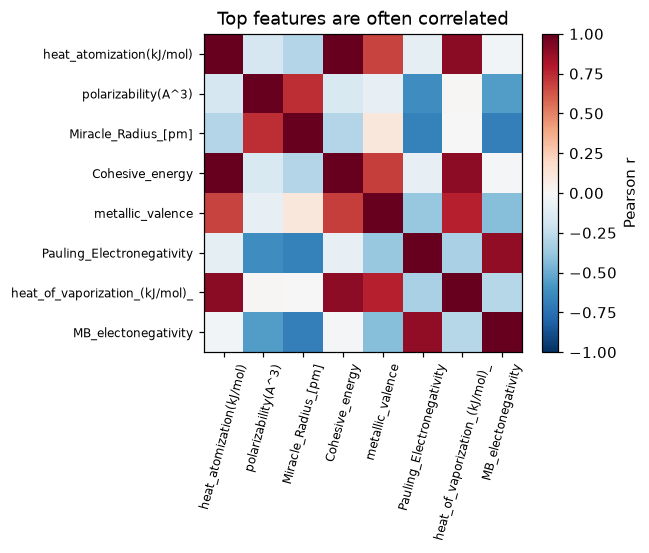

In [9]:
corr = X[perm.head(8).index].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), [c.replace("avg_", "") for c in corr.columns], rotation=75, fontsize=8)
ax.set_yticks(range(len(corr)), [c.replace("avg_", "") for c in corr.columns], fontsize=8)
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_title("Top features are often correlated")
plt.tight_layout()
plt.show()

## Part C — Extracting physical insight: partial dependence

A partial dependence plot (PDP) shows how the prediction changes as one feature varies, averaged over the data. It is a way to compare the model's learned trends with your physical intuition.

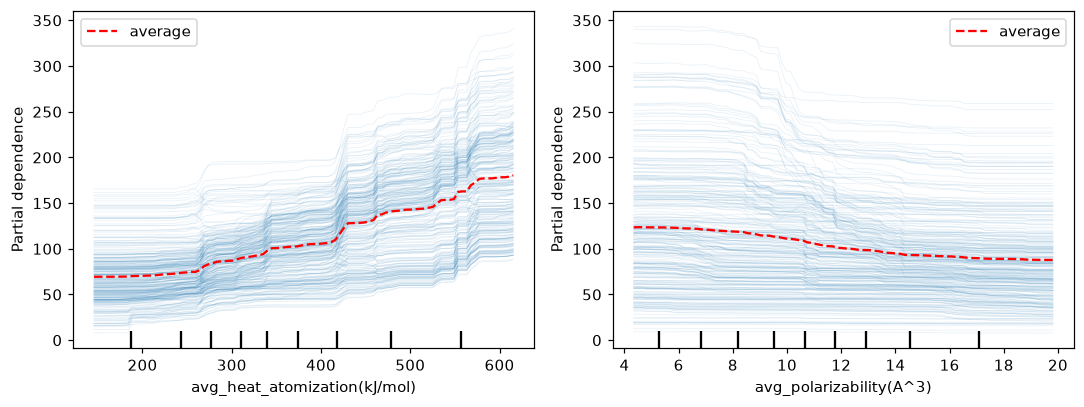

In [10]:
top2 = list(perm.index[:2])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
PartialDependenceDisplay.from_estimator(rf, X_te, top2, ax=ax, kind="both",
                                        subsample=300, random_state=RNG,
                                        ice_lines_kw={"alpha": 0.1}, pd_line_kw={"color": "red"})
plt.tight_layout()
plt.show()

**Discussion:** The model leans heavily on the **heat of atomization** (≈ cohesive energy) and **polarizability** (≈ atom size and softness). That is textbook physics: bulk modulus scales roughly with cohesive energy per unit volume, so strongly bonded, small, hard-to-polarize atoms (B, C, N, Os, Re…) make stiff solids. The model rediscovered this from data alone.

When a learned trend *contradicts* physics, the model has probably found a **dataset artifact**, which is valuable to know too.

## Part D — Uncertainty: how sure is the model?

A random forest is an ensemble. The spread of its trees' predictions gives a cheap (and imperfect) uncertainty estimate.

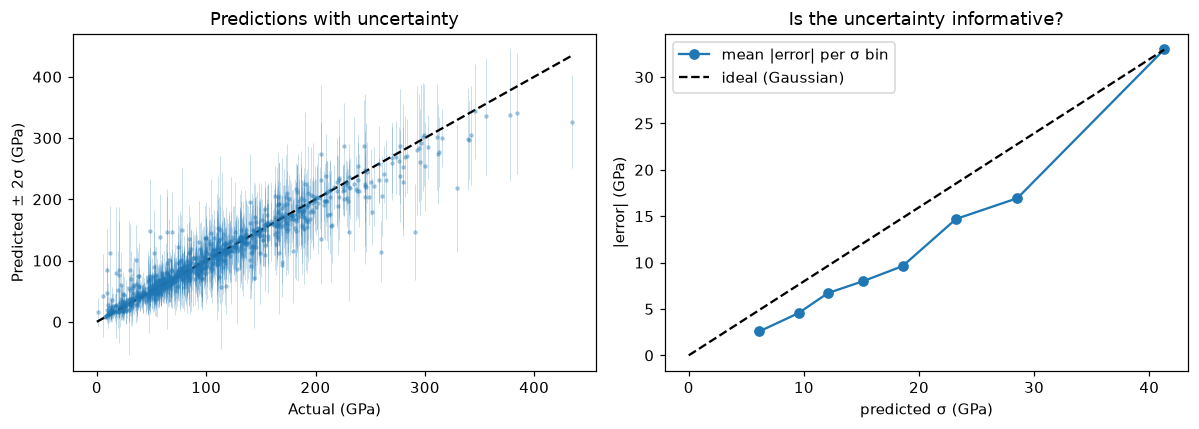

Fraction of test points inside ±2σ: 98.2%  (≈95% if well calibrated)


In [11]:
def rf_predict_with_std(model, X):
    all_preds = np.stack([t.predict(X.to_numpy()) for t in model.estimators_])
    return all_preds.mean(axis=0), all_preds.std(axis=0)

mu, sigma = rf_predict_with_std(rf, X_te)
abs_err = np.abs(y_te.to_numpy() - mu)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(y_te, mu, yerr=2 * sigma, fmt="o", ms=2, alpha=0.3, elinewidth=0.5)
lim = [0, y.max()]
axes[0].plot(lim, lim, "k--"); axes[0].set_xlabel("Actual (GPa)"); axes[0].set_ylabel("Predicted ± 2σ (GPa)")
axes[0].set_title("Predictions with uncertainty")

bins = pd.qcut(sigma, 8)
binned = pd.DataFrame({"sigma": sigma, "err": abs_err, "bin": bins}).groupby("bin", observed=True).mean()
axes[1].plot(binned["sigma"], binned["err"], "o-", label="mean |error| per σ bin")
axes[1].plot([0, binned["sigma"].max()], [0, binned["sigma"].max() * np.sqrt(2 / np.pi)], "k--",
             label="ideal (Gaussian)")
axes[1].set_xlabel("predicted σ (GPa)"); axes[1].set_ylabel("|error| (GPa)")
axes[1].set_title("Is the uncertainty informative?"); axes[1].legend()
plt.tight_layout()
plt.show()

coverage = np.mean(abs_err <= 2 * sigma)
print(f"Fraction of test points inside ±2σ: {coverage:.1%}  (≈95% if well calibrated)")

**Take-aways:** higher predicted σ → larger errors, so the *ranking* is useful (good for active learning in Session 5). But the raw σ is **miscalibrated**: here the ±2σ band covers more than 95% of points (too wide), and on other data it can be too narrow. Forest tree spread is not a true probability. If you need calibrated intervals, look at conformal prediction (e.g. the [`mapie`](https://github.com/scikit-learn-contrib/MAPIE) package) or Gaussian processes.

## Part E — When NOT to trust a model

### E1. A new chemistry: hold out all oxides
Random splits put oxides in both train and test. What if your application is oxides, but most of the training data isn't?

In [12]:
is_oxide = formulae.map(lambda f: "O" in parse_formula(f)).to_numpy()

m_random = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG).fit(X_tr, y_tr)
ox_te = is_oxide[X_te.index]
mae_random_ox = mean_absolute_error(y_te[ox_te], m_random.predict(X_te[ox_te]))

m_no_ox = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG).fit(X[~is_oxide], y[~is_oxide])
mae_new_chem = mean_absolute_error(y[is_oxide], m_no_ox.predict(X[is_oxide]))

print(f"MAE on oxides, random split (oxides seen in training): {mae_random_ox:.1f} GPa")
print(f"MAE on oxides, model never saw an oxide:              {mae_new_chem:.1f} GPa")

MAE on oxides, random split (oxides seen in training): 19.7 GPa
MAE on oxides, model never saw an oxide:              62.0 GPa


### E2. Extrapolating in the *target*: can we find a stiffer material than we've seen?
Discovery is about the extremes. Let's train only on compounds with B < 200 GPa and test on the stiffest ones.

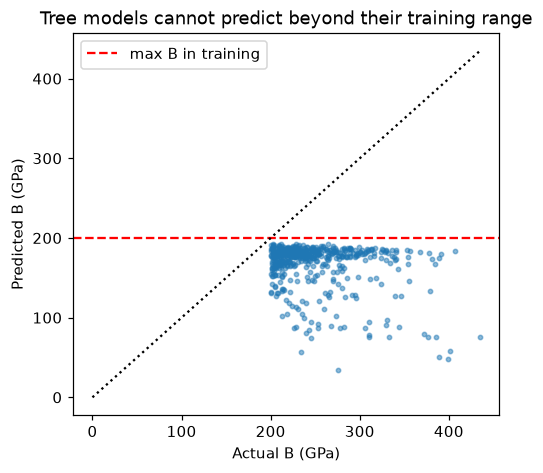

In [13]:
low = (y < 200).to_numpy()
m_low = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RNG).fit(X[low], y[low])
pred_high = m_low.predict(X[~low])

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(y[~low], pred_high, s=8, alpha=0.5)
ax.axhline(y[low].max(), color="red", ls="--", label="max B in training")
ax.plot([0, y.max()], [0, y.max()], "k:")
ax.set_xlabel("Actual B (GPa)"); ax.set_ylabel("Predicted B (GPa)")
ax.set_title("Tree models cannot predict beyond their training range")
ax.legend()
plt.show()

Tree-based models **cannot** predict above the largest value they saw. Linear models and GPs can extrapolate, but with no guarantee of being right. For discovery, the useful question is often *"which candidates are most likely to be at the top?"* rather than *"what is the exact value?"*. See Kauwe *et al.*, ["Can machine learning find extraordinary materials?"](https://doi.org/10.1016/j.commatsci.2019.109498).

### E3. Domain of applicability: is this compound "like" my training data?
A simple check is the distance from a new compound to its nearest training neighbor in (scaled) feature space.

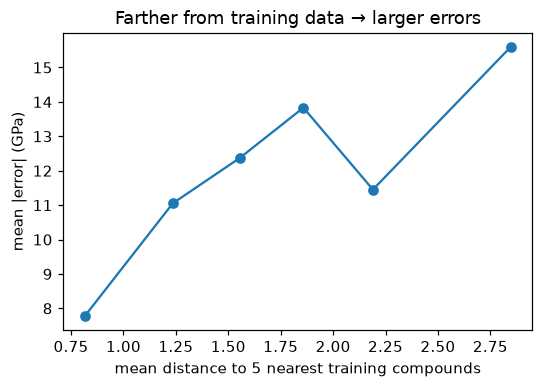

In [14]:
scaler = StandardScaler().fit(X_tr)
nn = NearestNeighbors(n_neighbors=5).fit(scaler.transform(X_tr))
dist = nn.kneighbors(scaler.transform(X_te))[0].mean(axis=1)

bins = pd.qcut(dist, 6)
summary = pd.DataFrame({"distance": dist, "abs_err": abs_err, "bin": bins}).groupby("bin", observed=True).mean()
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(summary["distance"], summary["abs_err"], "o-")
ax.set_xlabel("mean distance to 5 nearest training compounds")
ax.set_ylabel("mean |error| (GPa)")
ax.set_title("Farther from training data → larger errors")
plt.show()

### Checklist: when not to trust a prediction
- ❌ The compound has elements, or element *combinations*, that are rare or absent in training.
- ❌ It is far from the training data in feature space (E3), or its predicted σ is large (Part D).
- ❌ You're asking for a value outside the training range (E2).
- ❌ The validation scheme didn't mimic the real use case (Session 3, Part C).
- ❌ Important physics isn't in the features (structure, processing, defects; Session 2).
- ❌ The training labels came from a different method or definition than what you'll compare against (DFT vs. experiment).
- ✅ Use the model to **rank and prioritize**, then verify with experiment or simulation.

## Hands-on exercises
1. Repeat **E1** for nitrides or carbides. Which chemistry is hardest to transfer to?
2. Do the top permutation importances change if you use Magpie instead of Oliynyk features? What does that tell you about "important features"?
3. Pick 5 compositions from your own work. Predict B with σ and nearest-neighbor distance. Which predictions would you trust?

In [15]:
# Exercise 3 starter
from workshop_utils import featurize_formula
from workshop_utils import element_fractions

def canonical(formula):
    """'ZrO2', 'O2Zr1' and 'Zr2O4' all map to the same key."""
    return tuple(sorted((el, round(x, 4)) for el, x in element_fractions(formula).items()))

known = dict(zip(df.formula.map(canonical), df.target))
mine = ["Al2O3", "ZrO2", "Si3N4", "TiB2", "HfC", "MgAl2O4"]
Xm = pd.DataFrame([featurize_formula(f) for f in mine], index=mine)[X.columns]
mu_m, sd_m = rf_predict_with_std(rf, Xm)
d_m = nn.kneighbors(scaler.transform(Xm))[0].mean(axis=1)
pd.DataFrame({"pred B (GPa)": mu_m.round(0), "σ": sd_m.round(0), "NN distance": d_m.round(2),
              "DFT value in dataset": [known.get(canonical(f)) for f in mine]}, index=mine)

,pred B (GPa),σ,NN distance,DFT value in dataset
Al2O3,198.0,40.0,1.02,230.698
ZrO2,181.0,29.0,0.81,194.096
Si3N4,210.0,61.0,2.28,234.411
TiB2,235.0,30.0,0.89,244.488
HfC,177.0,35.0,1.54,158.306
MgAl2O4,173.0,26.0,1.05,183.639


*Note:* the dataset writes formulas like `O2Zr1`, so a naive string match for `ZrO2` fails. Matching compositions needs a canonical form (above), a classic data-cleaning gotcha. Compounds that *are* in the dataset may be in the training set, so their predictions are optimistic.

---
**Next session:** using models with uncertainty to choose the *next experiment*: Bayesian optimization and active learning.

**Go deeper:** full course `worked_examples/best_practices`, `worked_examples/gaussian_process` ·
Meredig *et al.*, ["Can machine learning identify the next high-temperature superconductor?"](https://doi.org/10.1039/C8ME00012C) (leave-cluster-out CV) ·
[Interpretable ML book](https://christophm.github.io/interpretable-ml-book/).